# DS202W Spring Term Summative
**Candidate Number:** [INSERT]

---

In [38]:
# === ALL IMPORTS ===
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from adjustText import adjust_text
import missingno as msno
from IPython.display import Markdown, display


# NLP / Text
import spacy
!python -m spacy download en_core_web_sm
import gensim
from gensim import corpora
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import networkx as nx

# Dimensionality Reduction
from sklearn.decomposition import PCA
from umap import UMAP

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from hdbscan import HDBSCAN

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Topic Modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Evaluation
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# Misc
from collections import Counter
from tqdm import tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 11.1 MB/s  0:00:01a 0:00:0136m0:00:01:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Dataset Choice

> **Why UK Petitions?**
>
> [Write a short paragraph here. Cover:
> - What you looked at across all three datasets
> - Why you ruled out Chicago (missingness in text field) and Glassdoor (short/formulaic text)
> - Why petitions won: richer text, multiple text layers, more signal for NLP methods, stronger basis for a research question]

After considering the goals of part a and part b, and briefly exploring each dataset, I decided to work with the petitions data. This project is mainly about working with textual data, and comes in two parts where using the same dataset for each adds the boon of continued analysis. The petitions data is text-rich, and has very long pieces of text data for some columns. The glassdoor dataset has short and formulaic text, which would force us to use embeddings over TF-IDF and hurt our ability to extract meaningful information. The chicago dataset has longer text but lots of text missingness, which would introduce distributional and democraphic biases that I would prefer not to work with. Documents in petitions will carry more signal, lend give performance improvements to models we select, and open up modelling decisions that might have been restricted by lack of signal in text data. The petitions data also has a floor of some text per row. Petitions also has an interesting subject matter which will make choosing a reseach question easier.

## 2. Data Loading & Reproducibility

> **Reproducibility instructions:**
> - Download the dataset from [source link]
> - Place the file as  in the repository root
> - The code below loads from this relative path

You can find information on where to download the data in the README. Data should live in the repo root and be named `uk_petitions_final.csv`. The code below loads from that relative path.

In [3]:
df = pd.read_csv("uk_petitions_final.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (11662, 20)


,petition_id,action,background,additional_details,state,signature_count,created_at,updated_at,rejected_at,opened_at,closed_at,government_response_at,debate_threshold_reached_at,scheduled_debate_date,debated,debate_overview,government_response_summary,government_response_body,rejection_code,rejection_details
0,700001,Fund reconstruction surgery and psychosexual t...,We urge the Government to support FGM survivor...,I know firsthand the physical and emotional ch...,closed,939,2024-10-30T14:20:17.653Z,2025-04-30T23:00:02.678Z,NaN,2024-10-31T17:30:30.989Z,2025-04-30T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,700005,Apply for the UK to join the European Union as...,I believe joining the EU would boost the econo...,I think the Single Market would bring inward i...,closed,136650,2024-10-30T14:28:44.914Z,2025-09-17T17:13:14.611Z,NaN,2024-10-31T17:46:29.187Z,2025-04-30T22:59:59.999Z,2024-11-19T14:28:18.247Z,2025-02-11T17:25:10.000Z,2025-03-24,NaN,NaN,The Government was elected on a manifesto that...,Since taking office this Government has been w...,NaN,NaN
2,700006,Rejoin the European Union,The UK Government should seek to rejoin the Eu...,The real black hole in the UK’s economy is all...,rejected,10,2024-10-30T14:32:33.904Z,2024-10-31T17:49:06.668Z,2024-10-31T17:48:58.550Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,duplicate,You may wish to sign this petition which calls...
3,700007,Require dating apps to ensure ID and DBS check...,I believe to better protect the public from of...,I believe that the ability for violent offende...,closed,1216,2024-10-30T14:34:44.936Z,2025-06-27T07:02:55.390Z,NaN,2024-11-05T18:42:41.810Z,2025-05-05T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,700009,"Fund Covid booster vaccines for all, with prio...",Long Covid can ruin lives and cause financial ...,"Currently, many Long Covid sufferers are unabl...",closed,716,2024-10-30T14:53:44.200Z,2025-06-05T23:00:05.025Z,NaN,2024-12-05T10:04:57.429Z,2025-06-05T22:59:59.999Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Profiling

> Inspect the structure of the dataset: column types, missingness, distributions of key fields.
> Pay special attention to which text columns are populated and for which subsets of petitions.

In [4]:
# Shape
df.shape

(11662, 20)

In [5]:
# Column types
df.dtypes

petition_id                      int64
action                             str
background                         str
additional_details                 str
state                              str
signature_count                  int64
created_at                         str
updated_at                         str
rejected_at                        str
opened_at                          str
closed_at                          str
government_response_at             str
debate_threshold_reached_at        str
scheduled_debate_date              str
debated                        float64
debate_overview                    str
government_response_summary        str
government_response_body           str
rejection_code                     str
rejection_details                  str
dtype: object

The document columns are `action`, `background`, `additional_details`, `debate_overview`, `goverment_response_summary`, `government_response_body`, and `rejection_details`. Some columns like `state`, `debated`, and `rejection_code` are all categorical. 

In [6]:
# Missingness
df.isnull().sum().sort_values(ascending=False)

debated                        11662
debate_overview                11661
scheduled_debate_date          11612
debate_threshold_reached_at    11596
government_response_body       11391
government_response_summary    11391
government_response_at         11391
closed_at                       8423
opened_at                       6441
rejection_details               5398
rejected_at                     5220
rejection_code                  5220
additional_details               570
action                             0
updated_at                         0
created_at                         0
signature_count                    0
state                              0
background                         0
petition_id                        0
dtype: int64

Every petition has action and background documents. Almost all of them have additional details, worth investigating why only some don't. Only a small percentage are actually debated, and all but one debate had a debate overview. Strangely, there are more petitions with opened at vals than closed at vals. I'm not sure if that will matter in part a but it might matter in part b.

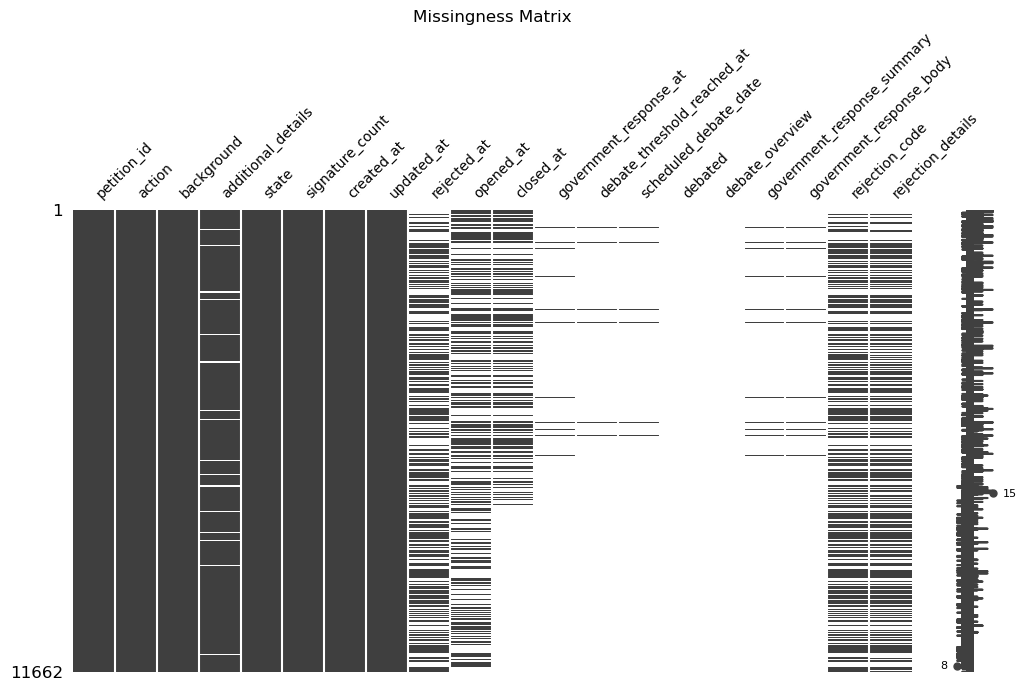

In [7]:
# Systematic Missingness
msno.matrix(df, figsize=(12, 6), fontsize=10)
plt.title("Missingness Matrix")
plt.show()

Missingness in additional details does not immediately appear systematic. Same with rejected at, opened at, but closed off has a cutoff. It appears that all cases are either rejected or opened. Lets check that, but first inspect to see if additional details is systematic missing. 

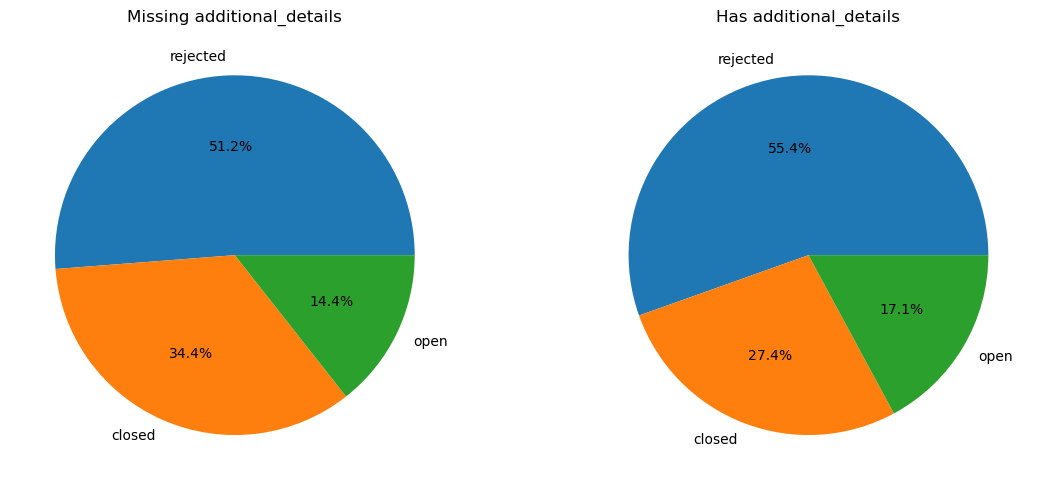

In [8]:
# Check proportion of state in missing and not missing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

missing = df[df['additional_details'].isnull()]['state'].value_counts()
not_missing = df[df['additional_details'].notna()]['state'].value_counts()

axes[0].pie(missing, labels=missing.index, autopct='%1.1f%%')
axes[0].set_title('Missing additional_details')

axes[1].pie(not_missing, labels=not_missing.index, autopct='%1.1f%%')
axes[1].set_title('Has additional_details')

plt.tight_layout()
plt.show()

Proportions across both charts indicate that missing additional details are not systematically related to state.

In [9]:
# Check missing additional details by signature count
df.groupby(df['additional_details'].isnull())['signature_count'].describe()

,count,mean,std,min,25%,50%,75%,max
additional_details,,,,,,,,
False,11092.0,1873.983502,32162.925382,4.0,7.0,21.0,79.0,2984192.0
True,570.0,8491.029825,136906.590847,6.0,8.0,21.0,92.0,3084715.0


Both have similar IQR marks, so I'm satisfied that there isn't discrimination based off of signature count. 

In [10]:
df['opened_at'].count() + df['rejected_at'].count()

11663

Total number of rows is 11662, so there is one row that occupies both, but I am going to count my suspicion as confirmed. 

In [11]:
# Distribution of petition states
df["state"].value_counts()

state
rejected    6442
closed      3239
open        1981
Name: count, dtype: int64

This gives us an even better picture. Petitions are either rejected, closed, or open.

In [12]:
# Text length distributions
text_cols = ["action", "background", "additional_details", "government_response_body", "rejection_details"]
for col in text_cols:
    non_null = df[col].dropna()
    print(f"{col}: {len(non_null)} non-null, mean length {non_null.str.len().mean():.0f} chars")

action: 11662 non-null, mean length 63 chars
background: 11662 non-null, mean length 216 chars
additional_details: 11092 non-null, mean length 365 chars
government_response_body: 271 non-null, mean length 3124 chars
rejection_details: 6264 non-null, mean length 260 chars


Actions are short statements, backgrounds and rejection details are concise paragraphs, additional details are regular paragraphs, but government responses are long, very long. Greater than an essay each. 

## 4. Exploratory Data Analysis

> Dig into the text data. Look at:
> - What do petitions actually look like? Read some examples across different states.
> - How do text fields relate to each other? (e.g., do petitions with government responses differ from rejected ones?)
> - Signature count distributions
> - Any patterns that might inform your Part A or Part B analysis

I want to start EDA by looking at a sample of our text documents. 

In [13]:
# Look at sample of lower-char documents
text_cols = ["action", "background", "additional_details", "rejection_details"]
md_lines = ["# EDA: Sample Petitions by State\n"]

# Sample stratified by state
for state in df["state"].unique():
    subset = df[df["state"] == state]

    # One q25 and q75 per state in the sample
    q25 = subset["signature_count"].quantile(0.25)
    q75 = subset["signature_count"].quantile(0.75)

    bottom = subset[subset["signature_count"] <= q25].sample(1, random_state=42)
    top = subset[subset["signature_count"] >= q75].sample(1, random_state=42)

    md_lines.append(f"## State: {state}\n")

    for label, row_df in [("Bottom Quartile", bottom), ("Top Quartile", top)]:
        row = row_df.iloc[0]
        md_lines.append(f"### {label} (Signatures: {int(row['signature_count']):,})\n")
        for col in text_cols:
            val = row.get(col, np.nan)
            content = str(val).strip() if pd.notna(val) else "N/A"
            md_lines.append(f"**{col}:**\n\n{content}\n")
        md_lines.append("---\n")

with open("sample_petitions.md", "w") as f:
    f.write("\n".join(md_lines))

display(Markdown("\n".join(md_lines)))

# EDA: Sample Petitions by State

## State: closed

### Bottom Quartile (Signatures: 35)

**action:**

Abolish Vehicle Excise Duty and add the cost to Fuel Duty

**background:**

I would like Vehicle Excise Duty (VED) to be completely abolished. Instead, add the cost to Fuel Duty. I think this will mean that for more fuel-efficient vehicles which generally use less fuel and emit less CO2, drivers will pay less for fuel, and this change may help wider zero carbon policies.

**additional_details:**

Older, less efficient vehicles can disappear naturally without some families potentially feeling forced into rash decisions about vehicle use.
 
In my view, any attempt to fast-track carbon reduction by hiking certain taxes like VED may make the country poorer. I think the infrastructure needed to do the things government wants to do is decades behind. I believe that it should be the case that the more fuel you use, the more tax you pay.

**rejection_details:**

N/A

---

### Top Quartile (Signatures: 1,657)

**action:**

Stop publicly funded legal aid to illegal immigrants

**background:**

We think that the government should stop publicly funded legal aid for illegal immigrants to fight their deportation.

**additional_details:**

N/A

**rejection_details:**

N/A

---

## State: rejected

### Bottom Quartile (Signatures: 6)

**action:**

Reform PMQs:Ban Misleading Claims,Ensure Answers,Enforce Speaker Accountability

**background:**

Reform PMQs as follows: Prohibition of Misleading Claims:An example being the "£22B Black Hole" claims, which are misleading. Mandatory Response to Questions: ensure PM answers questions. Speaker’s Role in Upholding Standards: enforce Speaker to acknowledge unanswered questions for accountability

**additional_details:**

The "£22B Black Hole" is debunked by fiscal experts including reports from the Office for Budget Responsibility, yet its use misleads the House, undermine public trust and the integrity of parliament

The Prime Minister must be held accountable for directly addressing questions posed during PMQs, evasion is weakening scrutiny

The Speaker must uphold accountability by noting unanswered questions

These reforms are urgent to restore trust in PMQs, ensuring transparency and democratic integrity

**rejection_details:**

We can't accept your petition because the UK Government and Parliament as a whole aren't responsible for the issue you raise. Order in the Commons is the responsibility of the Speaker personally, and the Prime Minister is responsible for answers to questions.

---

### Top Quartile (Signatures: 14)

**action:**

Improve resilience and safety of the M4 PoW Bridge and the M48 Severn Bridge

**background:**

Conduct a full review of the 9 December 2025 disruption, upgrade safety-critical infrastructure on both Severn bridges, strengthen wind-resilience, improve public communication, and publish a long-term strategy ensuring at least one crossing remains reliably open.

**additional_details:**

The simultaneous M4 and M48 closures exposed a major weakness in cross-Severn travel. These bridges are vital, and full shutdowns disrupt commuters, businesses and emergency services. We need an independent review to improve maintenance, weather-closure protocols, contingency planning, and to invest in reliable alternative routes. Stronger infrastructure and clearer communication are essential to prevent future total closures and protect the region’s connectivity.

**rejection_details:**

We can’t accept petitions that call for action at a local level.

You could ask your MP to take action on your concerns about this issue, including by asking them to present a public (paper) petition about this.

You can find contact details for your local MP here: https://members.parliament.uk/FindYourMP

And you can find out how to ask your MP to present a public (paper) petition here: https://www.parliament.uk/get-involved/sign-a-petition/paper-petitions/

You could also raise your issue with a local councillor who represents you. You can use this page to find out who your local councillors are, and how to contact them: https://www.gov.uk/find-your-local-councillors

---

## State: open

### Bottom Quartile (Signatures: 25)

**action:**

UC must cover housing costs following marriage breakdown in forces accommodation

**background:**

Following marriage breakdown in families living in in forces accommodation, the party occupying the property while seeking alternative accommodation can be classed as a 'trespasser', and may therefore be ineligible for support with housing costs through Universal Credit.

**additional_details:**

This can make it incredibly difficult for spouses going through a marriage separation. The word 'Trespass' means Universal Credit will often not help with the housing element of Universal Credit, so the spouse is eligible for the full cost. The spouse is given a breakdown of this cost for example water, council tax, garage rent, house rent and are expected to pay this rent and charges. This can leave families in financial difficulty, in debt when already struggling.

**rejection_details:**

N/A

---

### Top Quartile (Signatures: 623)

**action:**

Reduce VAT on hospitality to 10%: protect jobs, communities & UK competitiveness

**background:**

Reduce VAT on hospitality to 10% to prevent closures & protect tax revenue. When venues close, HMRC loses 100% of its VAT, business rates, PAYE & corporation tax, reducing employment & supply chains. We believe a lower VAT rate would keep viable businesses trading, securing jobs & ongoing revenue.

**additional_details:**

Hospitality businesses operate on very tight margins and struggle to absorb 20% VAT alongside rising food, energy, wage and rent costs. We believe a permanent reduction to 10% VAT would save jobs, keep venues open, support apprenticeships and skills, and strengthen high streets – it would help businesses survive and continue contributing billions to the UK economy.
 
This would protect local jobs, keep pubs and restaurants open, and help high streets, tourism and communities survive.

**rejection_details:**

N/A

---


This is interesting. First, I notice that signature count most likely has a correlation with acceptance. This could come from two angles; low sig counts could lead to rejection, or non-rejected petitions could gain more time to amass more sigs. I should be careful to draw causal relationships here.

About the text itself, I can already see that phrasing like "I think" vs "We think" may have an impact on acceptance. Another thing worth noting is how additional details don't make a lot of sense without background. Action provides a bit of a summary of the two and also poses the problem to be addressed. This could be relevant later in similarities. 

Background contains the benefit more often than not expresses the benefit of the action and why the proposers think so. The additional details gives context for why the issue is important. Including bigrams may alsobe useful. terms like illegal-immigrants have a very specific signal as opposed to illegal and immigrants seperately. These documents focus around the issue and the benefit, which can probably both be neatly identified by the keywords in action and the keywords in background and additional details. 

Because action seems to focus on the issue and background tends to focus on the benefit to be had, it could be possible to discern both based off of a bag-of-words based approach. 

Additional details seems like a summary of background and action, rephrasing similar points but with more illustration, like 'keep veues open' or 'for example water, council tax, garage rent...'; additional details is painting a picture where the other column documents are more to the point about the problem, the solution, and the benefit. 

The rejection details gave two different reasons but both represented a similar cause for rejection; the petitions were out of scope. This exposes one of what could be many rejection classes, where some are rejected on principle that they are out of scope, and others that are in scope are rejected for more nuanced reasons. 



In [14]:
# Select government response with median length
gov_responses = df[df["government_response_body"].notna()].copy()
gov_responses["gov_len"] = gov_responses["government_response_body"].str.len()
median_len = gov_responses["gov_len"].median()
median_row = gov_responses.iloc[(gov_responses["gov_len"] - median_len).abs().argsort()[:1]].iloc[0]

text = median_row["government_response_body"]
n = len(text)

md_lines = [
    "# EDA: Government Response Sample (Median Length)\n",
    f"**Petition action:** {median_row['action']}\n",
    f"**Signatures:** {int(median_row['signature_count']):,}\n",
    f"**Total length:** {n:,} chars\n",
    "---\n",
    "## First ~500 chars\n",
    f"{text[:500]}\n",
    "---\n",
    "## Middle ~500 chars\n",
    f"{text[n//2 - 250 : n//2 + 250]}\n",
    "---\n",
    "## Last ~500 chars\n",
    f"{text[-500:]}\n",
]

display(Markdown("\n".join(md_lines)))

# EDA: Government Response Sample (Median Length)

**Petition action:** Fund more staff training and better facilities in psychiatric hospitals

**Signatures:** 10,400

**Total length:** 3,062 chars

---

## First ~500 chars

The Government has confirmed that we will fulfil our commitment to recruit an additional 8,500 mental health workers for children and adults to ease pressure on busy mental health services by the end of the Parliament. We are more than halfway towards our target.  We will also publish a 10 Year Workforce Plan to create a workforce ready to deliver a transformed service. They will be more empowered, more flexible and more fulfilled. This will ensure the NHS has the right people in the right place

---

## Middle ~500 chars

ed to improving mental health accommodation. The NHS has invested £615 million to replace mental health dormitories with private rooms, following recommendations in the Independent Review of the Mental Health Act.  In addition, we have allocated £750 million over 2025-26 to address high-priority safety issues in NHS estates, including within mental health settings.  The 10 Year Health Plan sets out our vision for the neighbourhood health service. As part of this, we will transform the current me

---

## Last ~500 chars

anced rights and support, and ensure everyone is treated with dignity and respect throughout treatment.  NHS England’s mental health, learning disability and autism inpatient quality transformation programme will support cultural change and a new model of care for the future across all NHS-funded mental health inpatient settings. Local health systems have now published their 3-year plans for localising and realigning inpatient care in line with this vision.  Department of Health and Social Care 


These documents are very long, but on a text level appear to address the petitions in a structured way. They state an approach to the problem presented, walk though methodology and specifics, and then conclude with goals and how action is being taken. The fact that these contain a lot of reiteration of context and keywords, + the fact that there are far less government responses than useable datapoints makes me lean towards not using this column. 

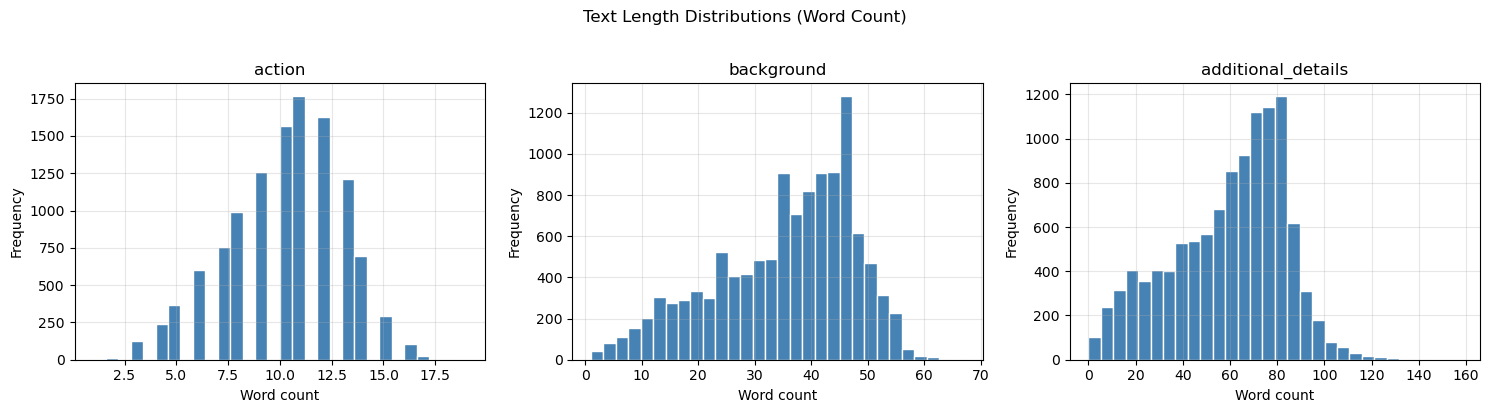

In [15]:
# Text length distributions (word count) for action, background, additional_details
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols = ["action", "background", "additional_details"]
 
for ax, col in zip(axes, cols):
    word_counts = df[col].dropna().str.split().str.len()
    ax.hist(word_counts, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{col}")
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)
 
fig.suptitle("Text Length Distributions (Word Count)", y=1.02)
plt.tight_layout()
plt.show()

Length is fairly normally distributed for actions, but background and additional details are heavily right skewed, with strong dropoffs at 50 and 80 words repectively. This could be because of an internally recommended length for both of these sections. Low values in background and additional details are not separated from their distributions, and don't necessarily appear to be outliers. Values on the high end are few and far between, suggesting that they are outliers. 

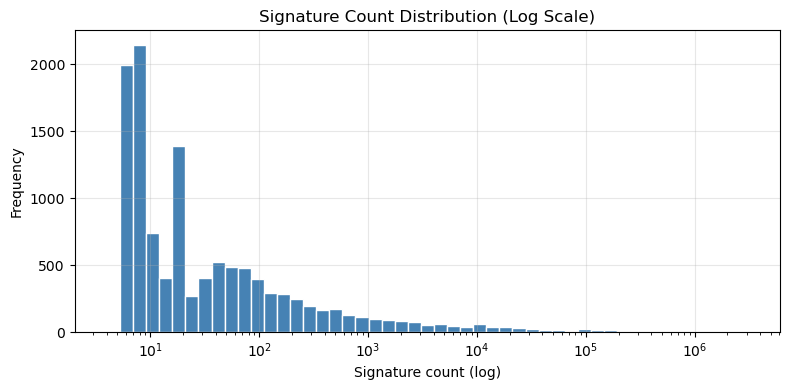

In [16]:
# Signature count distribution (log scale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["signature_count"], bins=np.logspace(np.log10(df["signature_count"].min()), np.log10(df["signature_count"].max()), 50), color="steelblue", edgecolor="white")
ax.set_xscale("log")
ax.set_title("Signature Count Distribution (Log Scale)")
ax.set_xlabel("Signature count (log)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Log scaled sig count is heavily left skewed. The peak around 10^1.1 is interesting, perhaps there is some minimum that guidelines recommend clearing? Regardless, there are many petitions with less than 10 signatures, and a smooth enough decline after. There do appear to be outliers on the right of the distribution. 

I'm leaning towards using just action, background, and additional details. Debate overview and government response inlcude interesting text data but are too sparse in our dataset for how I want to compare similarity and anomaly.

## 5. Subsampling

I'm working on a 2022 Mac Air M2 chip with 16gb ram, so 12k rows doesn't really call for subsampling. The heaviest thing I might run on this dataset is BERTopic because of the embedding + UMAP + HDBSCAN, but that still wouldn't take more than 15 mins max. I'll work with the whole set.

## 6. Text Preprocessing

> **Shared preprocessing pipeline for both parts.**
>
> Decisions to make:
> - Which text column(s) are you using? Just one, or combining multiple?
> - Tokenization, lowercasing, stopword removal, lemmatization: what choices and why?
> - Are there domain-specific preprocessing steps needed for petition text?
> - How do you handle petitions with missing text fields?

After exploring each text column during EDA, I chose to concatenate action, background, and additional_details into a single document per petition. Each column serves a distinct role: action states the problem and proposed solution, background argues the benefit, and additional_details illustrates and elaborates on the same points. While these roles differ, those distinctions are based on a small sample and remain assumptions. Concatenating extends document length from roughly 50 words to around 115 on average, strengthening signal for text representation methods like TF-IDF and embedding models that benefit from more context per document. This tradeoff favors signal strength over interpretability based on assumptions.

The roughly 570 petitions missing additional_details are dropped. Missingness was checked against petition state and signature count during profiling and found not to be systematic. Losing fewer than 5% of rows is a reasonable tradeoff for the boost in document length and consistency across the corpus.
government_response_body, rejection_details, and debate_overview are excluded. Government responses and debate overviews only exist for small, inherently biased subsets, and debate overview contains only a single non-null entry. Rejection details exist only for rejected petitions. Using any of these would restrict analysis to a non-representative subsample.

In [17]:
df = df.dropna(subset=['additional_details'])
df['petition_concat'] = df['action'] + ' ' + df['background'] + ' ' + df['additional_details']

I am going to use spaCy's `en_core_web_sm` to preprocess my data. The large version uses its own vectorization method, but I want to preserve choice of vectorization method for later. I might want TF-IDF for Part A and then sentence-transformers for Part B, or some other combo. For now, I just want to tokenize, lemmatize, and handle stopwords.

spaCy processes the text in one pass and labels each token with attributes like whether it's a stopword, punctuation, a number, etc. I then filter based on those labels. Specifically, I remove default spaCy stopwords, punctuation, and numbers. I also drop any single-character tokens, since meaningful single characters like "I" are already caught by stopword removal, and anything else at that length is noise. Tokens of length two and above are kept because abbreviations like "UK", "EU", and "AI" carry real signal in petition text. Lemmatization handles lowercasing implicitly since spaCy lemmas are lowercase.

I save two versions of the cleaned text: one with stopwords removed for methods like TF-IDF that benefit from it, and one with stopwords kept in case I use BERTopic later, which handles its own internal text representation and generally works better on more natural-sounding input.

Domain-specific stopwords like "government" or "petition" are not removed at this stage. I want to see post-preprocessing frequency data before making that call, rather than guessing upfront about what's too common to be useful.

In [18]:
nlp = spacy.load('en_core_web_sm')

def preprocess(doc, remove_stopwords=True):
    tokens = []
    for token in doc:
        if token.is_punct:
            continue
        if token.like_num:
            continue
        if len(token.text) < 2:
            continue
        if remove_stopwords and token.is_stop:
            continue
        tokens.append(token.lemma_.lower())
    return ' '.join(tokens)

docs = list(nlp.pipe(df['petition_concat'], batch_size=50))

df['cleaned_no_stopwords'] = [preprocess(doc, remove_stopwords=True) for doc in docs]
df['cleaned_with_stopwords'] = [preprocess(doc, remove_stopwords=False) for doc in docs]

Before removing any domain-specific stopwords, I want to see what's actually dominating the vocabulary. No point guessing when I can just look.

In [19]:
tokens = ' '.join(df['cleaned_no_stopwords']).split()
freq = Counter(tokens)
freq.most_common(50)

[('government', 8278),
 ('uk', 6695),
 ('people', 6280),
 ('think', 4810),
 ('child', 4570),
 ('public', 4108),
 ('believe', 4048),
 ('year', 3465),
 ('need', 3350),
 ('support', 2918),
 ('want', 2853),
 ('change', 2765),
 ('ensure', 2757),
 ('allow', 2629),
 ('school', 2549),
 ('law', 2529),
 ('work', 2525),
 ('protect', 2489),
 ('pay', 2354),
 ('time', 2304),
 ('help', 2261),
 ('right', 2157),
 ('family', 2149),
 ('stop', 2122),
 ('require', 2058),
 ('tax', 2055),
 ('ban', 2033),
 ('life', 1998),
 ('service', 1984),
 ('health', 1973),
 ('increase', 1925),
 ('system', 1915),
 ('reduce', 1902),
 ('like', 1860),
 ('use', 1721),
 ('cost', 1700),
 ('include', 1661),
 ('country', 1653),
 ('care', 1634),
 ('national', 1615),
 ('current', 1541),
 ('fund', 1536),
 ('feel', 1530),
 ('provide', 1527),
 ('review', 1521),
 ('introduce', 1507),
 ('act', 1506),
 ('new', 1503),
 ('leave', 1482),
 ('access', 1478)]

"Government" appears in over half the corpus and describes the medium, not the message. Dropping it as a domain-specific stopword. "UK" stays because it carries signal about nationwide vs. local scope.

In [20]:
df['cleaned_no_stopwords'] = df['cleaned_no_stopwords'].str.replace(r'\bgovernment\b', '', regex=True).str.strip()